In [ ]:
%pip install tensorflow==2.20.0 scikit-learn seaborn matplotlib pandas numpy sastrawi nltk

In [1]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import json
import math
from collections import Counter

import datetime as dt
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Kompatibel untuk NLTK versi baru yang membutuhkan resource punkt_tab.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
DATA_PATH = Path("content/reviews_hok.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "File /content/reviews_hok.csv belum ditemukan. Jalankan notebook scrapping.ipynb terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape data awal:", df.shape)
df.head()

Shape data awal: (12000, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,2c793cc6-a533-4756-899c-929fe0905f1f,com.levelinfinite.sgameGlobal,Honor of King,Muhammad Ramadani,5,"game nya seru, developer nya baik, heronya balance daripada moba lain. hal yang aku permasalahkan; sering kali layar...",11,2026-04-03 14:50:36,11.3.1.8
1,03d587fa-daa9-4a40-b7c0-31ad6207ec45,com.levelinfinite.sgameGlobal,Honor of King,Andriyanto,2,"tolong perbaiki peforma peningkatan sinyal nya, kadang yang diutamakan itu pengalaman bermain, tolong perbaiki serve...",2,2026-04-23 17:57:13,11.3.1.9
2,f9f2926a-cfd2-4c77-b668-48813c845d28,com.levelinfinite.sgameGlobal,Honor of King,Andika,2,"gamenya udah bagus cuma ada kekurangan di fitur download, yaitu skin dalam match (yang dimiliki) sama yang (belum di...",1,2026-04-25 07:25:37,11.3.1.9
3,6febf65b-1bcd-4893-879a-03b7679ea16c,com.levelinfinite.sgameGlobal,Honor of King,icooo,1,"game rusak game rusak, lain kali kalo update jangan cuma mikirin skin,collab,dll. pentingin juga optimalisasi jaring...",0,2026-04-27 08:59:50,11.3.1.9
4,7a0f84f8-5c43-497a-b6c2-35b045d29061,com.levelinfinite.sgameGlobal,Honor of King,Nur Juminati,5,"Suka banget sama game nya, soalnya hero nya juga kebanyakan cakep-cakep:b. Cuma ya.. Kekurangan nya itu cuma satu, j...",1,2026-04-24 00:44:56,11.3.1.9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    12000 non-null  str  
 1   app_id       12000 non-null  str  
 2   app_name     12000 non-null  str  
 3   user_name    12000 non-null  str  
 4   score        12000 non-null  int64
 5   content      12000 non-null  str  
 6   thumbs_up    12000 non-null  int64
 7   at           12000 non-null  str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 843.9 KB


In [ ]:
clean_df = df.dropna()
clean_df = clean_df.drop_duplicates()

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    12000 non-null  str  
 1   app_id       12000 non-null  str  
 2   app_name     12000 non-null  str  
 3   user_name    12000 non-null  str  
 4   score        12000 non-null  int64
 5   content      12000 non-null  str  
 6   thumbs_up    12000 non-null  int64
 7   at           12000 non-null  str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 843.9 KB


In [27]:
display(clean_df["score"].value_counts().sort_index())

score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

In [28]:
clean_df = clean_df.copy()
clean_df["sentiment_seed"] = clean_df["score"].astype(int).map(
    lambda score: "negative" if score <= 2 else ("neutral" if score == 3 else "positive")
)

print("Distribusi score:")
display(clean_df["score"].value_counts().sort_index())

print("Total data untuk training:", len(clean_df))


Distribusi score:


score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

Total data untuk training: 9008


Mencari Slangword

In [29]:
INPUT_FILE = "content/reviews_hok.csv"
TEXT_COLUMN = "content"

MIN_FREQ = 5
OUTPUT_JSON = "slangwords_hok_scored.json"
OUTPUT_CSV = "slangwords_hok_scored.csv"
OUTPUT_STRICT_CSV = "slangwords_hok_scored_strict.csv"

# =========================
# LEXICON
# =========================

SLANG_LEXICON = {
    # negasi
    "gak": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "tdk": "tidak",
    "tak": "tidak",

    # kata informal umum
    "yg": "yang",
    "aja": "saja",
    "udah": "sudah",
    "udh": "sudah",
    "blm": "belum",
    "belom": "belum",
    "bgt": "banget",
    "banget": "sangat",
    "bgtt": "banget",
    "kalo": "kalau",
    "kalau": "jika",
    "buat": "untuk",
    "pas": "saat",
    "padahal": "sebenarnya",
    "kayak": "seperti",
    "kek": "seperti",
    "kyk": "seperti",
    "sama": "dengan",
    "sm": "sama",
    "dgn": "dengan",
    "dr": "dari",
    "krn": "karena",
    "karna": "karena",
    "tp": "tapi",
    "tpi": "tapi",
    "cuma": "hanya",
    "doang": "saja",
    "banget": "sangat",
    "nih": "ini",
    "sih": "",
    "dong": "",
    "lah": "",
    "deh": "",
    "kok": "mengapa",
    "emang": "memang",
    "emg": "memang",
    "mending": "lebih baik",
    "makin": "semakin",
    "gede": "besar",
    "kecil": "kecil",
    "burik": "buruk",
    "jelek": "buruk",
    "bagus": "baik",

    # pronomina informal
    "aku": "saya",
    "gue": "saya",
    "gw": "saya",
    "gua": "saya",
    "lu": "kamu",
    "lo": "kamu",
    "loe": "kamu",
    "dia": "ia",
    "mereka": "mereka",

    # ekspresi umum
    "mantap": "baik",
    "mantul": "mantap betul",
    "parah": "sangat buruk",
    "anjir": "ungkapan kaget",
    "anjay": "ungkapan kaget",
    "wkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",

    # variasi typo / informal game review
    "pengen": "ingin",
    "pingin": "ingin",
    "bikin": "membuat",
    "ngasih": "memberi",
    "ngasih": "memberikan",
    "dapet": "dapat",
    "dpt": "dapat",
    "mainin": "memainkan",
    "maen": "main",
    "mabar": "main bersama",
    "login": "masuk",
    "ngeleg": "lambat",
    "ngelag": "lambat",
    "lag": "lambat",
    "lemot": "lambat",
    "bug": "kesalahan sistem",
    "error": "kesalahan sistem",
    "crash": "keluar paksa",
    "freeze": "macet",
}

GAMING_LEXICON = {
    "hero": "karakter",
    "skin": "tampilan karakter",
    "rank": "peringkat",
    "match": "pertandingan",
    "game": "permainan",
    "moba": "genre permainan",
    "player": "pemain",
    "team": "tim",
    "tim": "tim",
    "server": "server",
    "ping": "latensi",
    "fps": "frame per second",
    "buff": "peningkatan kemampuan",
    "nerf": "penurunan kemampuan",
    "skill": "kemampuan",
    "ulti": "kemampuan utama",
    "ultimate": "kemampuan utama",
    "mmr": "peringkat pemain",
    "meta": "strategi populer",
    "lane": "jalur permainan",
    "jungler": "pemain hutan",
    "roam": "berpindah jalur",
    "roamer": "pemain pendukung",
    "gold": "sumber daya permainan",
    "exp": "pengalaman",
    "push": "menekan jalur",
    "war": "pertarungan tim",
    "afk": "tidak aktif",
    "bot": "pemain komputer",
    "toxic": "perilaku buruk",
    "skin": "tampilan karakter",
    "diamond": "mata uang permainan",
    "event": "acara permainan",
    "patch": "pembaruan",
    "update": "pembaruan",
}

# Kata baku/umum yang sebaiknya tidak dianggap slang.
FORMAL_STOPWORDS = {
    "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan", "pada",
    "adalah", "sebagai", "dalam", "atau", "karena", "jika", "agar",
    "lebih", "sangat", "bisa", "akan", "sudah", "belum", "tidak",
    "yang", "saya", "kamu", "kami", "mereka", "orang", "ada",
    "jadi", "harus", "semua", "setiap", "saat", "terlalu",
}

# =========================
# PREPROCESSING
# =========================

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_series(texts):
    tokens = []
    for text in texts:
        tokens.extend(clean_text(text).split())
    return tokens


# =========================
# RULES
# =========================

def has_repeated_char(word: str) -> bool:
    return bool(re.search(r"(.)\1{2,}", word))


def normalize_repeated_char(word: str) -> str:
    """
    Contoh:
    enakkk -> enak
    baguss -> bagus
    mantapp -> mantap
    """
    return re.sub(r"(.)\1{2,}", r"\1", word)


def is_short_abbreviation(word: str) -> bool:
    return len(word) <= 4 and not word.isdigit()


def is_noise(word: str) -> bool:
    if len(word) <= 1:
        return True
    if word.isdigit():
        return True
    if re.fullmatch(r"[0-9]+[a-z]*", word):
        return True
    return False


def classify_word(word: str):
    """
    Return:
    normalisasi, category, method
    """

    if word in SLANG_LEXICON:
        return SLANG_LEXICON[word], "informal_slang", "direct_lexicon"

    if word in GAMING_LEXICON:
        return GAMING_LEXICON[word], "gaming_term", "direct_lexicon"

    repeated_normalized = normalize_repeated_char(word)
    if repeated_normalized != word:
        if repeated_normalized in SLANG_LEXICON:
            return SLANG_LEXICON[repeated_normalized], "informal_slang", "repeated_char_normalization"
        if repeated_normalized in FORMAL_STOPWORDS:
            return repeated_normalized, "informal_slang", "repeated_char_normalization"
        return repeated_normalized, "informal_slang", "repeated_char_pattern"

    # kandidat singkatan informal
    if is_short_abbreviation(word):
        if word not in FORMAL_STOPWORDS:
            return None, "informal_slang", "short_abbreviation_pattern"

    return None, None, None


# =========================
# CONFIDENCE SCORE
# =========================

def compute_confidence(word, freq, category, method):
    """
    Score dibuat agar:
    - direct lexicon + frekuensi tinggi mendekati 0.99
    - pattern-based lebih rendah
    """

    # frequency score logarithmic supaya kata sangat sering dominan,
    # tapi tidak membuat semua kata otomatis 0.99
    freq_score = min(math.log1p(freq) / math.log1p(3500), 1.0)

    method_weight = {
        "direct_lexicon": 0.55,
        "repeated_char_normalization": 0.42,
        "repeated_char_pattern": 0.32,
        "short_abbreviation_pattern": 0.25,
    }.get(method, 0.2)

    category_weight = {
        "informal_slang": 0.25,
        "gaming_term": 0.20,
        "domain_term": 0.18,
    }.get(category, 0.15)

    score = method_weight + category_weight + (freq_score * 0.25)

    return round(min(score, 0.99), 3)


# =========================
# MAIN EXTRACTOR
# =========================

def extract_slangwords(
    input_file=INPUT_FILE,
    text_column=TEXT_COLUMN,
    min_freq=MIN_FREQ,
):
    df = pd.read_csv(input_file)

    if text_column not in df.columns:
        raise ValueError(
            f"Kolom '{text_column}' tidak ditemukan. "
            f"Kolom tersedia: {list(df.columns)}"
        )

    tokens = tokenize_series(df[text_column].fillna(""))
    frequencies = Counter(tokens)

    results = []

    for word, freq in frequencies.items():
        if freq < min_freq:
            continue

        if is_noise(word):
            continue

        normalisasi, category, method = classify_word(word)

        if category is None:
            continue

        confidence_score = compute_confidence(
            word=word,
            freq=freq,
            category=category,
            method=method,
        )

        results.append({
            "slangword": word,
            "normalisasi": normalisasi,
            "frequency": freq,
            "confidence_score": confidence_score,
            "category": category,
            "method": method,
        })

    results = sorted(
        results,
        key=lambda x: (-x["confidence_score"], -x["frequency"], x["slangword"])
    )

    return results


# =========================
# RUN
# =========================

if __name__ == "__main__":
    results = extract_slangwords()

    # JSON
    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print("Saved:", OUTPUT_JSON)

Saved: slangwords_hok_scored.json


In [30]:
SLANGWORDS_PATH = Path("slangwords_hok_scored.json")
if not SLANGWORDS_PATH.exists():
    raise FileNotFoundError(
        "File slangwords_hok_scored.json tidak ditemukan di root project."
    )

with SLANGWORDS_PATH.open("r", encoding="utf-8") as f:
    slangwords_raw = json.load(f)

# Ubah list of dict JSON menjadi mapping: slankword -> normalisasi
slangwords = {
    item["slangword"].strip().lower(): item["normalisasi"].strip().lower()
    for item in slangwords_raw
    if item.get("slangword") and item.get("normalisasi")
}

print(f"Total slangwords termuat: {len(slangwords)}")


Total slangwords termuat: 137


In [31]:
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        key = word.lower()
        if key in slangwords:
            fixed_words.append(slangwords[key])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


In [32]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text, preserve_line=True)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [33]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [34]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [35]:
# Fungsi untuk menentukan polaritas sentimen berbasis lexicon
def sentiment_analysis_lexicon_indonesia(tokens):
    score = 0

    for word in tokens:
        # Tambah bobot jika kata ada di kamus positif
        score += lexicon_positive.get(word, 0)
        # Kurangi bobot jika kata ada di kamus negatif
        score += lexicon_negative.get(word, 0)

    if score < 0:
        polarity = 'negative'
    elif score >= 0:
        polarity = 'positive'

    return score, polarity

In [36]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    5906
positive    3102
Name: count, dtype: int64


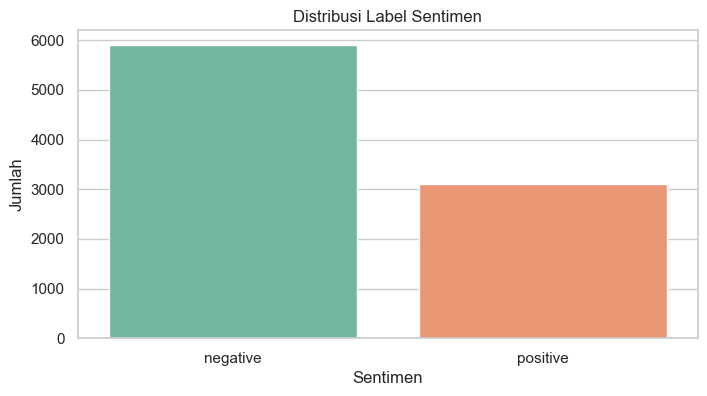

polarity
negative    5906
positive    3102
Name: count, dtype: int64

In [37]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=clean_df,
    x="polarity",
    order=["negative", "positive"],
    palette="Set2",
    hue="polarity",
    legend=False
  )
ax.set_title("Distribusi Label Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")
plt.show()

clean_df["polarity"].value_counts()

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']
 
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)
 
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
 
# Menampilkan hasil ekstraksi fitur
features_df
 

,acara,adil,aktif,akun,aman,aneh,banget,beda,beli,bener,...,tim,tolong,tombol,top,trus,tuh,turun,uang,ulang,wifi
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.135464,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.214873,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.277180,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.257487
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.118811,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.421341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9003,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9004,0.241635,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.303522,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9005,0.534946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9006,0.387342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.474171,0.0,0.0,0.000000


In [39]:

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

## Relabeling: 3 Kelas Sentimen (negative / neutral / positive)

Distribusi 3 Kelas Sentimen:
polarity
negative    5514
positive    2065
neutral     1429
Name: count, dtype: int64
Total sampel: 9008


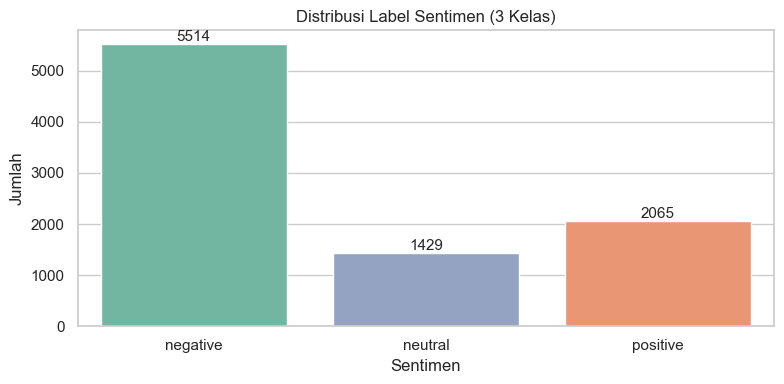

In [50]:
# Fungsi labeling 3 kelas: negative (score<0), neutral (score==0), positive (score>0)
def sentiment_3class(tokens):
    score = 0
    for word in tokens:
        score += lexicon_positive.get(word, 0)
        score += lexicon_negative.get(word, 0)
    if score < -1:
        polarity = 'negative'
    elif -1 <= score <= 1:
        polarity = 'neutral'
    else:
        polarity = 'positive'
    return score, polarity

results_3 = clean_df['text_stopword'].apply(sentiment_3class)
results_3 = list(zip(*results_3))
clean_df['polarity_score'] = results_3[0]
clean_df['polarity'] = results_3[1]

print('Distribusi 3 Kelas Sentimen:')
print(clean_df['polarity'].value_counts())
print(f'Total sampel: {len(clean_df)}')

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=clean_df, x='polarity',
    order=['negative', 'neutral', 'positive'],
    palette='Set2', hue='polarity', legend=False
)
ax.set_title('Distribusi Label Sentimen (3 Kelas)')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder

# Re-fit TF-IDF dengan lebih banyak fitur untuk deep learning
X_text = clean_df['text_akhir']
y_labels = clean_df['polarity']

tfidf_3 = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
X_tfidf_3 = tfidf_3.fit_transform(X_text)

# Encode label ke integer (alphabetical: negative=0, neutral=1, positive=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print('Kelas:', le.classes_)

# Split 80/20 untuk Skema 1
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf_3, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)
X_train_dense = X_train_tf.toarray()
X_test_dense  = X_test_tf.toarray()
print(f'Train: {X_train_dense.shape}, Test: {X_test_dense.shape}')

# Hitung class weights untuk menangani imbalance
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}
print('Class weights:', class_weight_dict)

# Helper fungsi evaluasi
def evaluate_model(y_true, y_pred, scheme_name, classes):
    acc = accuracy_score(y_true, y_pred)
    print()
    print(f'=== {scheme_name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=classes))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {scheme_name}')
    plt.ylabel('Label Sebenarnya')
    plt.xlabel('Label Prediksi')
    plt.tight_layout()
    plt.show()
    return acc

Kelas: ['negative' 'neutral' 'positive']
Train: (7206, 5000), Test: (1802, 5000)
Class weights: {0: 0.508409527034654, 1: 4.819689673622258, 2: 1.2112410918381067}


## Skema Deep Learning

In [48]:
# Konfigurasi umum untuk 3 skema
MAX_TOKENS = 15000
SEQ_LEN = 120

callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)
]

def normalize_text_for_model(series_or_array):
    s = pd.Series(series_or_array).astype(str)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return np.asarray(s.values, dtype=str)

def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title_prefix} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title_prefix} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def evaluate_dl(y_true, y_pred, scheme_name, classes):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f'=== {scheme_name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Macro F1 : {macro_f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {scheme_name}')
    plt.ylabel('Label Sebenarnya')
    plt.xlabel('Label Prediksi')
    plt.tight_layout()
    plt.show()
    return acc, macro_f1

def make_bilstm_model(vectorizer, max_tokens=MAX_TOKENS):
    inp = keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inp)
    x = layers.Embedding(input_dim=max_tokens, output_dim=200)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inp, out, name='BiLSTM_Model')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def make_textcnn_model(vectorizer, max_tokens=MAX_TOKENS):
    inp = keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inp)
    x = layers.Embedding(input_dim=max_tokens, output_dim=200)(x)

    conv3 = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    conv4 = layers.Conv1D(128, 4, activation='relu', padding='same')(x)
    conv5 = layers.Conv1D(128, 5, activation='relu', padding='same')(x)

    pool3 = layers.GlobalMaxPooling1D()(conv3)
    pool4 = layers.GlobalMaxPooling1D()(conv4)
    pool5 = layers.GlobalMaxPooling1D()(conv5)

    merged = layers.Concatenate()([pool3, pool4, pool5])
    z = layers.Dense(128, activation='relu')(merged)
    z = layers.Dropout(0.4)(z)
    out = layers.Dense(3, activation='softmax')(z)

    model = keras.Model(inp, out, name='TextCNN_Model')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def make_hybrid_model(vectorizer, max_tokens=MAX_TOKENS):
    inp = keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inp)
    x = layers.Embedding(input_dim=max_tokens, output_dim=200)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Bidirectional(layers.LSTM(96))(x)
    x = layers.Dense(96, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inp, out, name='Hybrid_CNN_BiLSTM_Model')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results_table = []
trained_models = {}

## Skema A: BiLSTM (TextVectorization + Embedding, split 80/20)

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_3            │ (None, 120)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 120, 200)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 120, 256)       │       336,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,179 (12.86 MB)

 Trainable params: 3,370,179 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 45s 357ms/step - accuracy: 0.6372 - loss: 0.9048 - val_accuracy: 0.7297 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 343ms/step - accuracy: 0.8239 - loss: 0.5159 - val_accuracy: 0.7619 - val_loss: 0.5931 - learning_rate: 0.0010
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 43s 379ms/step - accuracy: 0.9030 - loss: 0.3069 - val_accuracy: 0.7137 - val_loss: 0.8184 - learning_rate: 0.0010
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 387ms/step - accuracy: 0.9409 - loss: 0.2010 - val_accuracy: 0.7375 - val_loss: 0.8266 - learning_rate: 0.0010
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 334ms/step - accuracy: 0.9796 - loss: 0.0646 - val_accuracy: 0.7897 - val_loss: 0.7304 - learning_rate: 5.0000e-04
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 37s 323ms/step - accuracy: 0.9918 - loss: 0.0275 - val_accuracy: 0.7980 - val_loss: 0.8043 - learning_rate: 5.0000e-04
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - accur

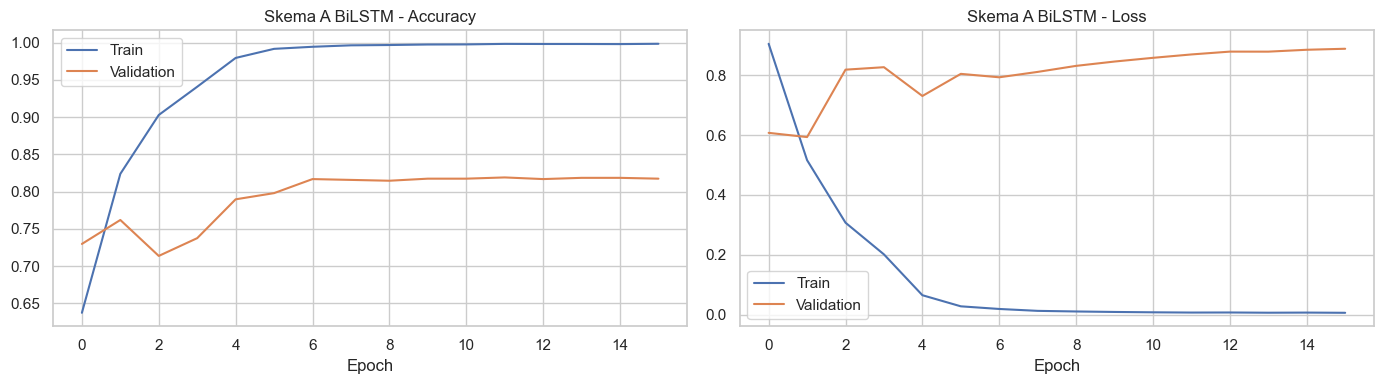

=== Skema A: BiLSTM (80/20) ===
Accuracy : 0.8191
Macro F1 : 0.6758
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90      1181
     neutral       0.29      0.43      0.34       125
    positive       0.79      0.78      0.78       496

    accuracy                           0.82      1802
   macro avg       0.67      0.70      0.68      1802
weighted avg       0.84      0.82      0.83      1802



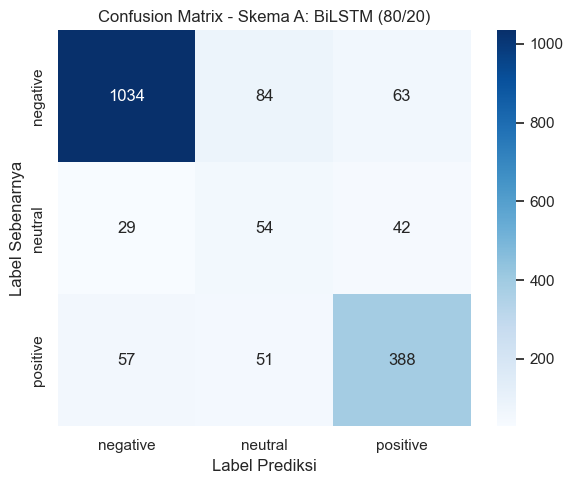

In [49]:
X_text_clean = normalize_text_for_model(X_text)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_text_clean, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)
X_train_a_tf = tf.constant(np.asarray(X_train_a, dtype=str).reshape(-1, 1), dtype=tf.string)
X_test_a_tf = tf.constant(np.asarray(X_test_a, dtype=str).reshape(-1, 1), dtype=tf.string)

vectorizer_a = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=SEQ_LEN
)
vectorizer_a.adapt(np.asarray(X_train_a, dtype=str))

model_a = make_bilstm_model(vectorizer_a)
model_a.summary()

history_a = model_a.fit(
    X_train_a_tf, y_train_a,
    validation_data=(X_test_a_tf, y_test_a),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)
plot_history(history_a, 'Skema A BiLSTM')

y_pred_a = np.argmax(model_a.predict(X_test_a_tf, verbose=0), axis=1)
acc_a, f1_a = evaluate_dl(y_test_a, y_pred_a, 'Skema A: BiLSTM (80/20)', le.classes_)

results_table.append({
    'Skema': 'Skema A',
    'Model': 'BiLSTM',
    'Fitur': 'TextVectorization + Embedding',
    'Split': '80/20',
    'Train Accuracy (best)': float(max(history_a.history['accuracy'])),
    'Test Accuracy': float(acc_a),
    'Test Macro F1': float(f1_a)
})
trained_models['Skema A'] = model_a

## Tuning Skema A (BiLSTM)


===== Training A_v1_conservative =====
Epoch 1/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 50s 195ms/step - accuracy: 0.5511 - loss: 1.6634 - val_accuracy: 0.7458 - val_loss: 1.3339 - learning_rate: 5.0000e-04
Epoch 2/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 43s 188ms/step - accuracy: 0.7502 - loss: 1.0446 - val_accuracy: 0.8324 - val_loss: 0.9288 - learning_rate: 5.0000e-04
Epoch 3/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 43s 188ms/step - accuracy: 0.8439 - loss: 0.7844 - val_accuracy: 0.7958 - val_loss: 0.8544 - learning_rate: 5.0000e-04
Epoch 4/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.8993 - loss: 0.6273 - val_accuracy: 0.7370 - val_loss: 1.0424 - learning_rate: 5.0000e-04
Epoch 5/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9285 - loss: 0.5249 - val_accuracy: 0.8307 - val_loss: 0.8552 - learning_rate: 5.0000e-04
Epoch 6/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9620 - loss: 0.4284 - val_accuracy: 0.7947 - val_loss: 0.9392 - learning_rate: 2.5000e-04
=== Sk

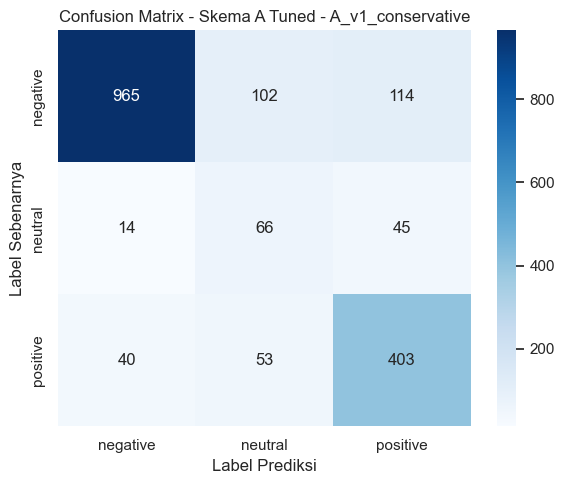


===== Training A_v2_balanced =====
Epoch 1/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - accuracy: 0.5960 - loss: 1.2735 - val_accuracy: 0.7492 - val_loss: 1.1347 - learning_rate: 7.0000e-04
Epoch 2/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - accuracy: 0.7845 - loss: 0.8288 - val_accuracy: 0.7836 - val_loss: 0.8092 - learning_rate: 7.0000e-04
Epoch 3/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - accuracy: 0.8714 - loss: 0.6089 - val_accuracy: 0.8130 - val_loss: 0.7526 - learning_rate: 7.0000e-04
Epoch 4/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 53s 233ms/step - accuracy: 0.9213 - loss: 0.4757 - val_accuracy: 0.8119 - val_loss: 0.8415 - learning_rate: 7.0000e-04
Epoch 5/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 57s 250ms/step - accuracy: 0.9512 - loss: 0.3831 - val_accuracy: 0.7891 - val_loss: 0.9821 - learning_rate: 7.0000e-04
Epoch 6/16
226/226 ━━━━━━━━━━━━━━━━━━━━ 61s 270ms/step - accuracy: 0.9675 - loss: 0.3275 - val_accuracy: 0.7952 - val_loss: 0.9536 - learning_rate: 3.5000e-04
=== Skema 

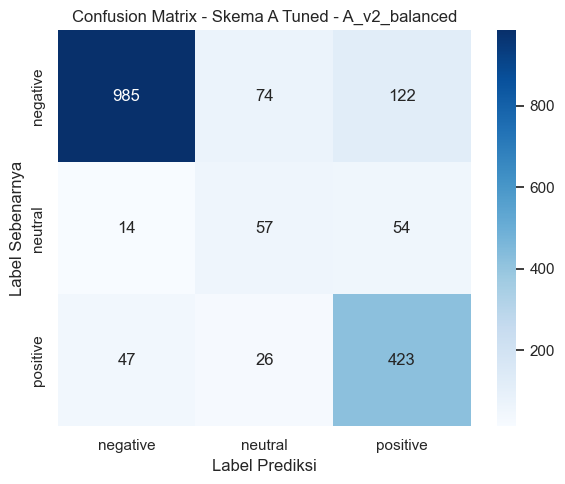


===== Training A_v3_strong_reg =====
Epoch 1/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 33s 176ms/step - accuracy: 0.5354 - loss: 1.4866 - val_accuracy: 0.7092 - val_loss: 1.3130 - learning_rate: 6.0000e-04
Epoch 2/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.7027 - loss: 1.0171 - val_accuracy: 0.8257 - val_loss: 1.0551 - learning_rate: 6.0000e-04
Epoch 3/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 173ms/step - accuracy: 0.7998 - loss: 0.8012 - val_accuracy: 0.8241 - val_loss: 0.7788 - learning_rate: 6.0000e-04
Epoch 4/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.8683 - loss: 0.6186 - val_accuracy: 0.8302 - val_loss: 0.6755 - learning_rate: 6.0000e-04
Epoch 5/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 27s 176ms/step - accuracy: 0.9066 - loss: 0.5085 - val_accuracy: 0.7958 - val_loss: 0.7562 - learning_rate: 6.0000e-04
Epoch 6/16
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.9331 - loss: 0.4368 - val_accuracy: 0.7925 - val_loss: 0.8557 - learning_rate: 6.0000e-04
Epoch 7/

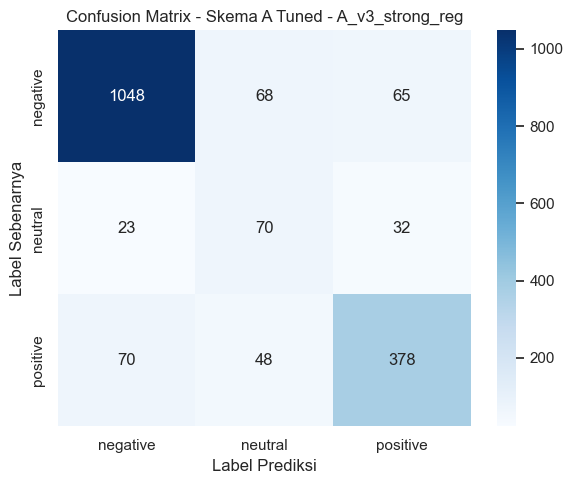

,Config,Test Accuracy,Test Macro F1,Best Train Accuracy,Best Val Accuracy
0,A_v3_strong_reg,0.830189,0.710470,0.949487,0.830189
1,A_v2_balanced,0.812986,0.687152,0.967527,0.812986
2,A_v1_conservative,0.795782,0.673530,0.961976,0.832408


Best Skema A config: A_v3_strong_reg
Best Test Accuracy: 0.8302
Best Test Macro F1: 0.7105


In [51]:
from tensorflow.keras import regularizers

# Reuse split dari Skema A agar adil saat membandingkan performa
if 'X_train_a' not in globals() or 'X_test_a' not in globals():
    X_text_clean = normalize_text_for_model(X_text)
    X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
        X_text_clean, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
    )

A_TUNE_CONFIGS = [
    {
        'name': 'A_v1_conservative',
        'emb_dim': 128,
        'lstm_units': 80,
        'dense_units': 64,
        'spatial_dropout': 0.20,
        'recurrent_dropout': 0.20,
        'dense_dropout': 0.50,
        'l2': 1e-3,
        'lr': 5e-4,
        'batch_size': 32,
        'epochs': 16,
    },
    {
        'name': 'A_v2_balanced',
        'emb_dim': 150,
        'lstm_units': 96,
        'dense_units': 80,
        'spatial_dropout': 0.25,
        'recurrent_dropout': 0.15,
        'dense_dropout': 0.45,
        'l2': 5e-4,
        'lr': 7e-4,
        'batch_size': 32,
        'epochs': 16,
    },
    {
        'name': 'A_v3_strong_reg',
        'emb_dim': 100,
        'lstm_units': 64,
        'dense_units': 48,
        'spatial_dropout': 0.30,
        'recurrent_dropout': 0.25,
        'dense_dropout': 0.50,
        'l2': 8e-4,
        'lr': 6e-4,
        'batch_size': 48,
        'epochs': 16,
    },
]

def build_bilstm_a_tuned(vectorizer, cfg):
    inp = keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inp)
    x = layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=cfg['emb_dim'],
        embeddings_regularizer=regularizers.l2(cfg['l2'])
    )(x)
    x = layers.SpatialDropout1D(cfg['spatial_dropout'])(x)
    x = layers.Bidirectional(
        layers.LSTM(
            cfg['lstm_units'],
            return_sequences=True,
            recurrent_dropout=cfg['recurrent_dropout'],
            kernel_regularizer=regularizers.l2(cfg['l2'])
        )
    )(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
        cfg['dense_units'],
        activation='relu',
        kernel_regularizer=regularizers.l2(cfg['l2'])
    )(x)
    x = layers.Dropout(cfg['dense_dropout'])(x)
    out = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inp, out, name=cfg['name'])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

a_tuning_rows = []
best_bundle = None

for cfg in A_TUNE_CONFIGS:
    print(f"\n===== Training {cfg['name']} =====")

    vectorizer_tune = layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode='int',
        output_sequence_length=SEQ_LEN
    )
    vectorizer_tune.adapt(np.asarray(X_train_a, dtype=str))

    X_train_tf_tune = tf.constant(np.asarray(X_train_a, dtype=str).reshape(-1, 1), dtype=tf.string)
    X_test_tf_tune = tf.constant(np.asarray(X_test_a, dtype=str).reshape(-1, 1), dtype=tf.string)

    model_tune = build_bilstm_a_tuned(vectorizer_tune, cfg)

    callbacks_tune = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6),
    ]

    history_tune = model_tune.fit(
        X_train_tf_tune, y_train_a,
        validation_data=(X_test_tf_tune, y_test_a),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        class_weight=class_weight_dict,
        callbacks=callbacks_tune,
        verbose=1
    )

    y_pred_tune = np.argmax(model_tune.predict(X_test_tf_tune, verbose=0), axis=1)
    acc_tune, f1_tune = evaluate_dl(y_test_a, y_pred_tune, f"Skema A Tuned - {cfg['name']}", le.classes_)

    a_tuning_rows.append({
        'Config': cfg['name'],
        'Test Accuracy': float(acc_tune),
        'Test Macro F1': float(f1_tune),
        'Best Train Accuracy': float(max(history_tune.history['accuracy'])),
        'Best Val Accuracy': float(max(history_tune.history['val_accuracy'])),
    })

    if best_bundle is None or f1_tune > best_bundle['f1']:
        best_bundle = {
            'config': cfg['name'],
            'model': model_tune,
            'vectorizer': vectorizer_tune,
            'history': history_tune,
            'acc': float(acc_tune),
            'f1': float(f1_tune),
        }

tuning_df = pd.DataFrame(a_tuning_rows).sort_values(
    by=['Test Macro F1', 'Test Accuracy'], ascending=False
).reset_index(drop=True)

display(tuning_df)
print(f"Best Skema A config: {best_bundle['config']}")
print(f"Best Test Accuracy: {best_bundle['acc']:.4f}")
print(f"Best Test Macro F1: {best_bundle['f1']:.4f}")

# Override model A dengan versi tuning terbaik
model_a = best_bundle['model']
trained_models['Skema A Tuned'] = model_a